This is a script to initally segment a session-long EEG recording (acquired during an MRI session with three relevant functional scans) and generate a pseudo-ECG channel to use for de-noising the ballistocardiogram artefact. It begins with gradient-artefact-corrected data in EGI's proprietary file format.

The script should be run for each subject separately, with manual QC performed by close inspection of the generated plots.

Author: Mary Miedema, 2025

# Set-up

Configure script with scan parameters and file locations, including those of pulse metrics derived from concurrently acquired physiological data.

In [1]:
import os
import numpy as np
import mne
import matplotlib.pyplot as plt
from scipy.io import loadmat
from copy import deepcopy


input_root = "E://eeg_pipeline//EGI_gradcorr//"
ppg_root = "E://eeg_pipeline//ppg//"
output_root = 'E://eeg_pipeline//EEGlab_preBCG//'
fig_root = 'E://eeg_pipeline//QC_plots//'

EEG_segs_labels = ['rest','breathing', 'visual']
TR = 1030 # msec

subject_id = '2888'

# find the corresponding eeg file
for x in os.listdir(input_root):
    if x.startswith('SUB'+subject_id):
        eeg_fname = input_root+x
        print(x)

# load in PPG metrics for this subject
mat_fname = ppg_root+subject_id+'_ses03.mat'
mat_contents = loadmat(mat_fname)
PPG_metrics = mat_contents['sub_HRs']
# can call PPG_metrics[i] to get the [mean_HR max_HR std_HR ms_between_HR]


SUB2888_ses03_20241216_034412_mrr.mff


Initialize EEG data

In [ ]:
EEG = mne.io.read_raw_egi(input_fname=eeg_fname,preload=True)
EEG.info['line_freq'] = 60  # specify power line frequency
EEG.info
#EEG.plot()

Reading EGI MFF Header from E:\eeg_pipeline\EGI_gradcorr\SUB2888_ses03_20241216_034412_mrr.mff...
    Reading events ...
    Assembling measurement info ...
    Excluding events {TREV} ...
Reading 0 ... 2951839  =      0.000 ...  2951.839 secs...
Using qt as 2D backend.


<mne_qt_browser._pg_figure.MNEQtBrowser(0x1776a231eb0) at 0x000001776B656600>

Channels marked as bad:
none


c:\Users\data_acq\mne-python\1.9.0_0\Lib\site-packages\mne_qt_browser\_pg_figure.py:3061: RuntimeWarning: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()


Find the sequence segments

[600.0000000000001, 399.9999999999998, 569.9999999999999]


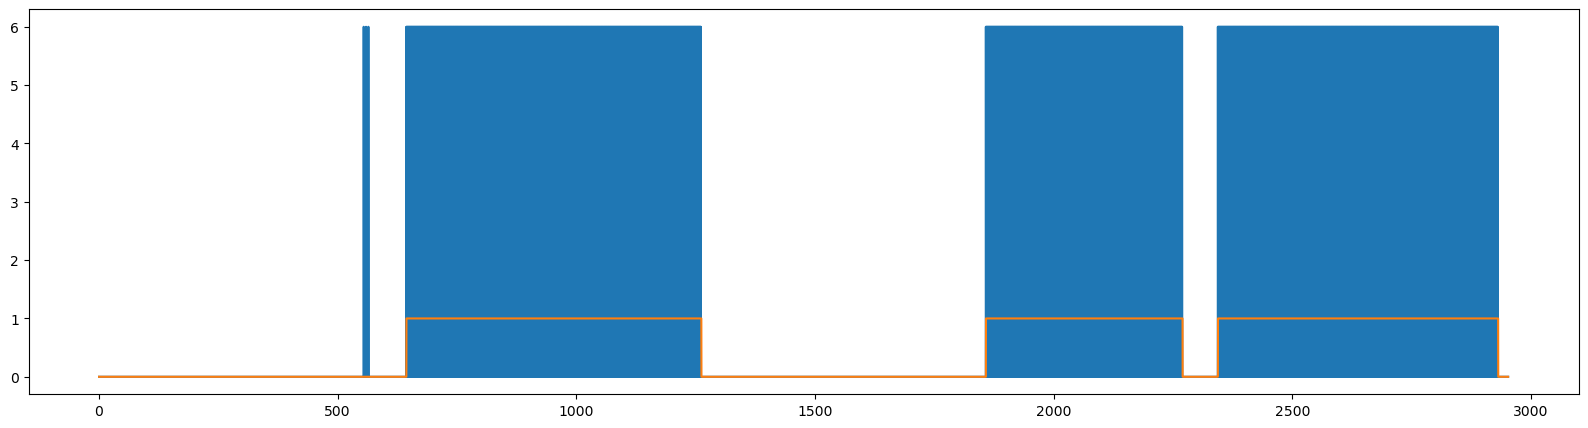

In [ ]:
# segment into separate scans
events = mne.find_events(EEG, stim_channel='TREV', verbose=0)

if subject_id == '8116':
    events = np.insert(events, 0, [1, 0, 6],axis=0)

margin = 4 # number of samples

diffs = np.diff(events[:,0])
nonfunc_indices = np.where(diffs > TR+margin)
# we will look for the three functional scans ONLY
nonfunc_indices = nonfunc_indices[0]
epochs = list()
for i, diff_ind in enumerate(nonfunc_indices):
    if i == len(nonfunc_indices)-1:
        start = events[diff_ind+1,0]
        stop = events[-1,0]
    else:
        start = events[diff_ind+1,0]
        stop = events[nonfunc_indices[i+1],0]
    if stop - start > margin:
        epochs.append([start, stop+TR])

# handling some peculiar scans:
if subject_id == '9922':
    epochs = epochs[0:2]

if subject_id == '8803':
    epochs = epochs[2:]

TREV, times = EEG.get_data(
    picks='TREV', 
    # tmin=500, tmax=1000, 
    return_times=True
) 
epochs_rep = np.zeros(np.shape(times))
epoch_lengths = list()
for i, ep in enumerate(epochs):
    epoch_length = times[ep[1]]-times[ep[0]]
    epoch_lengths.append(epoch_length)
    epochs_rep[ep[0]:ep[1]] = 1
    #print(epochs[0,i])
fig = plt.figure(figsize=(20,5))
plt.plot(times, TREV[0])
plt.plot(times, epochs_rep)

QC_fig_path = fig_root+'scan_seg_'+subject_id+'.png'
fig.savefig(QC_fig_path)

n_vols = [x * 1000 / TR for x in epoch_lengths]
print(n_vols)
# number of volumes for each segment, should be [600, 400, 570] for [rest, breathing, visual] tasks respectively

In [12]:
# chunk the EEG  into scans
EEG_segs = list()
for i, epoch in enumerate(epochs):
    new_EEG = EEG.copy()
    new_EEG.crop(tmin=times[epoch[0]+TR], tmax=times[epoch[1]]) # now discarding the first volume to avoid artefact!
    EEG_segs.append(new_EEG)

In [ ]:
# note the presence of the gradient artefact during the last MR volume, this will need to be discarded
#selected_channels = ['E123', 'E124', 'TREV'] 
#EEG.plot(picks=selected_channels, duration=10, start=(times[epoch[1]]-5)) 

<mne_qt_browser._pg_figure.MNEQtBrowser(0x177b36be0d0) at 0x0000017775EA9BC0>

Channels marked as bad:
none


c:\Users\data_acq\mne-python\1.9.0_0\Lib\site-packages\mne_qt_browser\_pg_figure.py:3061: RuntimeWarning: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()


### Next, simulate an ECG channel to correct the ballistocardiogram artefact and save each functional segment as a new EEG dataset compatible with further use in EEGlab
Note that the simulated channel is interchangeably referred to as a pseudo-ECG channel and BCG channel.

First, select channels that should be most susceptible to this pulse-locked artefact and use them to approximate the overall BCG (method following Iannotti et al., 2015)

In [ ]:
# choose a symmetrical set of strongly susceptible channels

# EEG.plot_sensors(kind='topomap',show_names=True)
#picks_L = ['E49','E48','E43','E128','E127']
#picks_R = ['E113','E119','E120','E125','E126']
#picks_L = ['E49','E48','E43','E128','E32','E25']
#picks_R = ['E113','E119','E120','E125','E1','E8']
picks_L = ['E49','E48','E43','E128','E32','E25','E127','E44','E38','E56']
picks_R = ['E113','E119','E120','E125','E1','E8','E126','E121','E114','E107']
# found that the resulting averages are quite stable, across all of the above picks

BCGs = list()
for i, EEG_i in enumerate(EEG_segs):
    data_L, times = EEG_i.get_data(picks=picks_L,return_times=True)
    data_R = EEG_i.get_data(picks=picks_R)
    BCG = np.mean(data_R,axis=0) - np.mean(data_L,axis=0)

    plt.figure(figsize=(20,5))
    snip = [20,30]
    # plot an example of the artefact: you should be able to see it quite easily!
    plt.plot(times,data_L[3,:],color='blue')
    plt.plot(times,data_R[3,:],color='red')
    plt.plot(times,BCG,linewidth=3,color='black')
    plt.xlim(snip)
    BCG_snip = BCG[snip[0]*1000:snip[1]*1000]
    new_ylim = [1.5*np.min(BCG_snip),1.5*np.max(BCG_snip)]
    plt.ylim(new_ylim)
    plt.title(EEG_segs_labels[i])

    BCGs.append(BCG)

Now simulating BCG detection channel for rest
The simulated BCG channel has a base mean HR of:  64.84567866122114  compared to the PPG mean: 65.6920931094312
The simulated BCG channel has a base std HR of:  6.864639834894998  compared to the PPG std: 5.728418494207359
The simulated BCG channel has a corrected mean HR of:  65.09231487483667  compared to the PPG mean: 65.6920931094312
The simulated BCG channel has a corrected std HR of:  7.9593939004104755  compared to the PPG std: 5.728418494207359
Now simulating BCG detection channel for breathing
The simulated BCG channel has a base mean HR of:  63.51622297999384  compared to the PPG mean: 64.23327432168601
The simulated BCG channel has a base std HR of:  7.652787684849921  compared to the PPG std: 6.426744143611547
The simulated BCG channel has a corrected mean HR of:  63.85361926073053  compared to the PPG mean: 64.23327432168601
The simulated BCG channel has a corrected std HR of:  8.909174547972276  compared to the PPG std: 6.4267

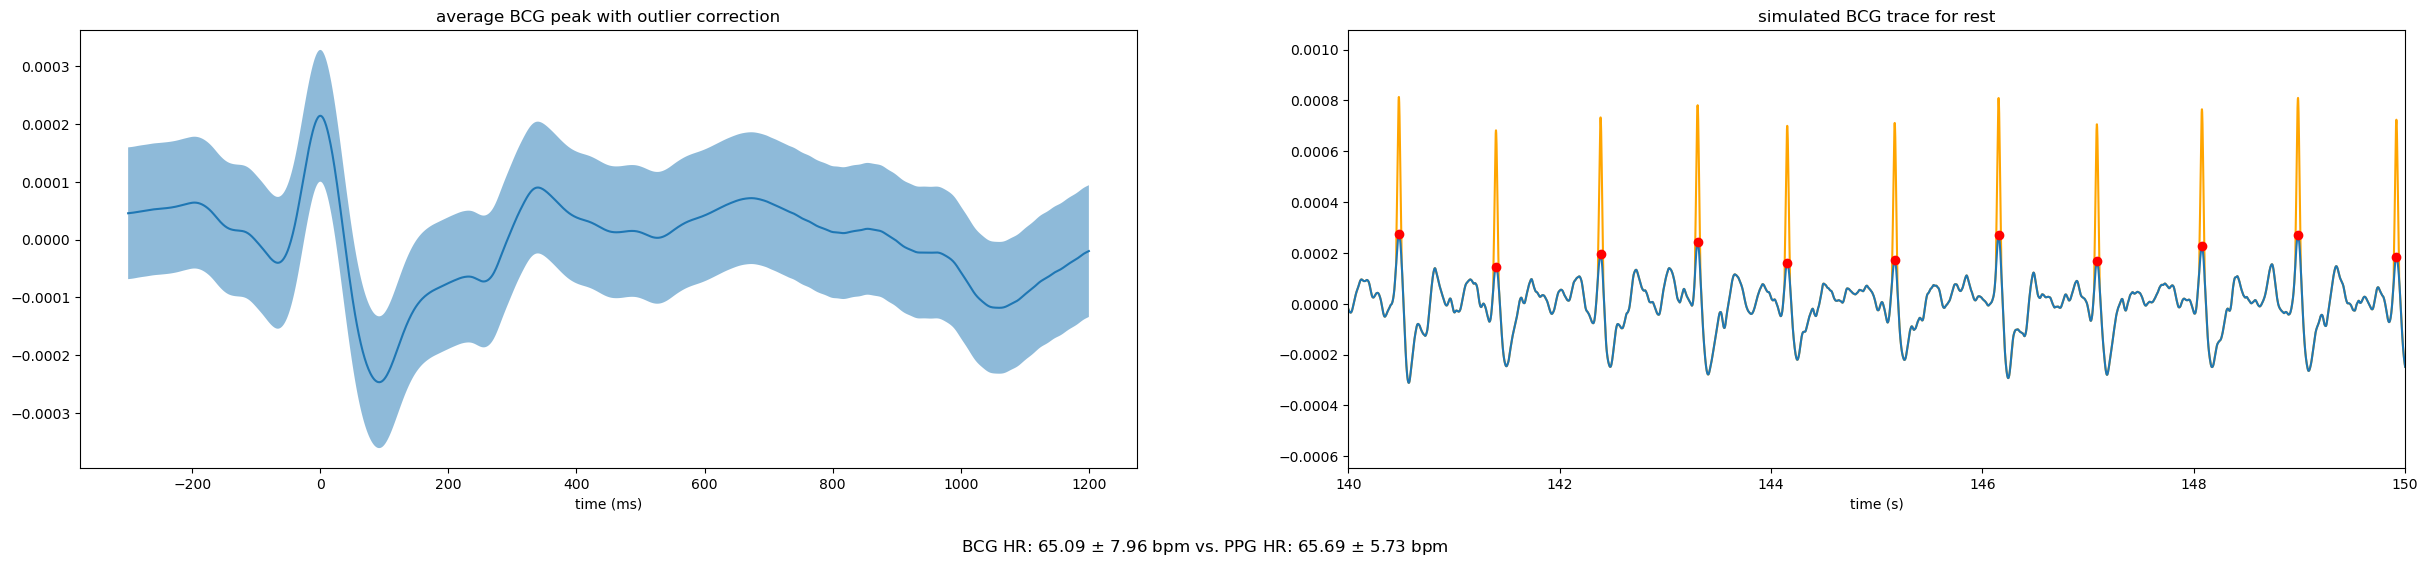

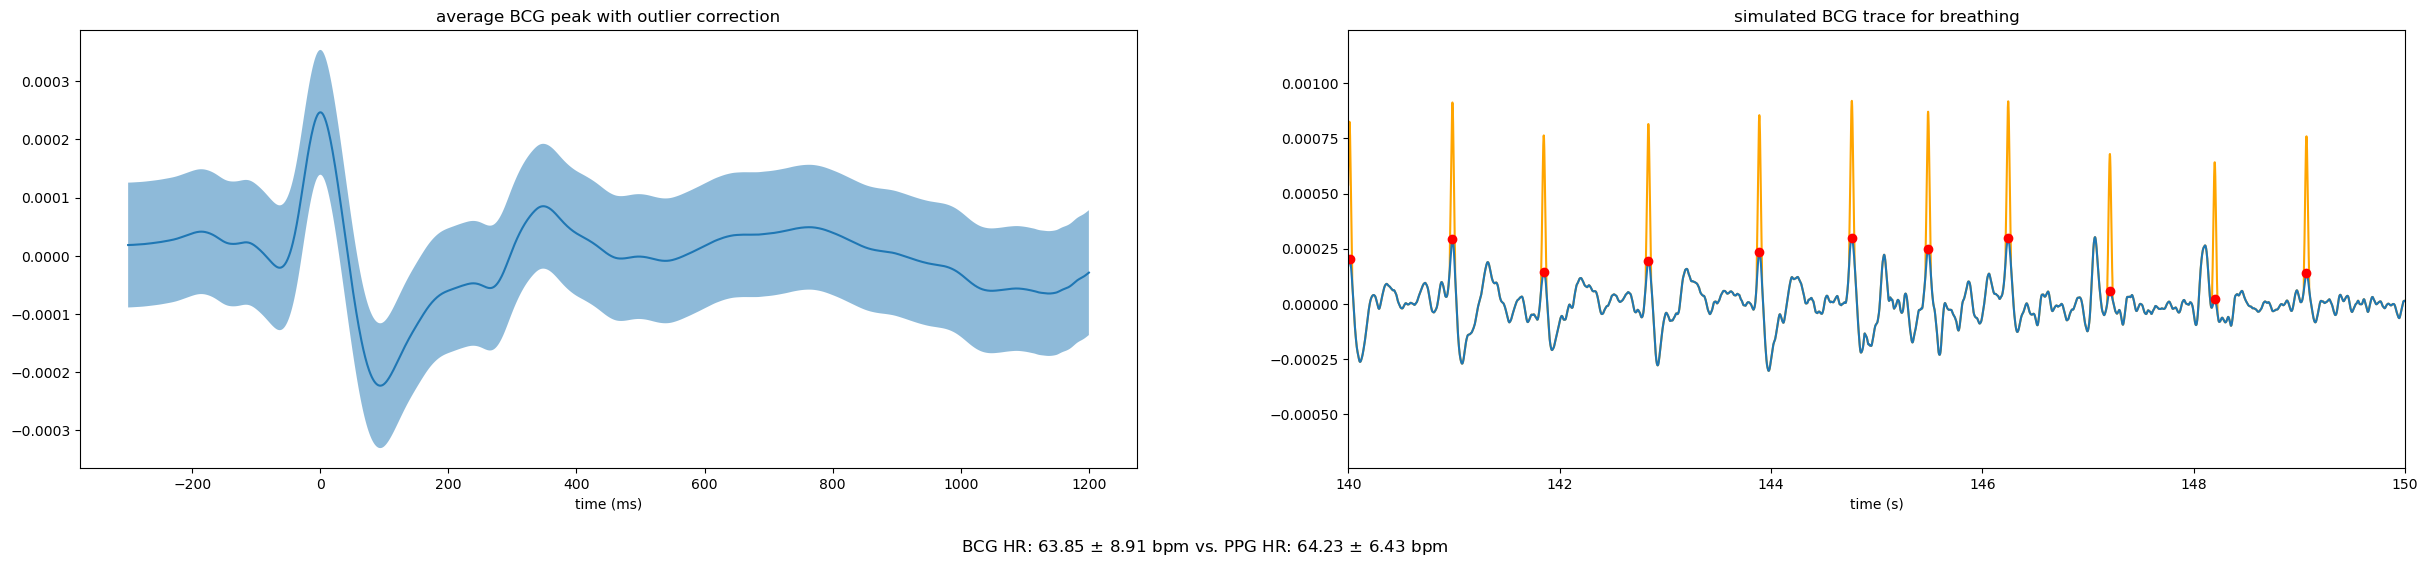

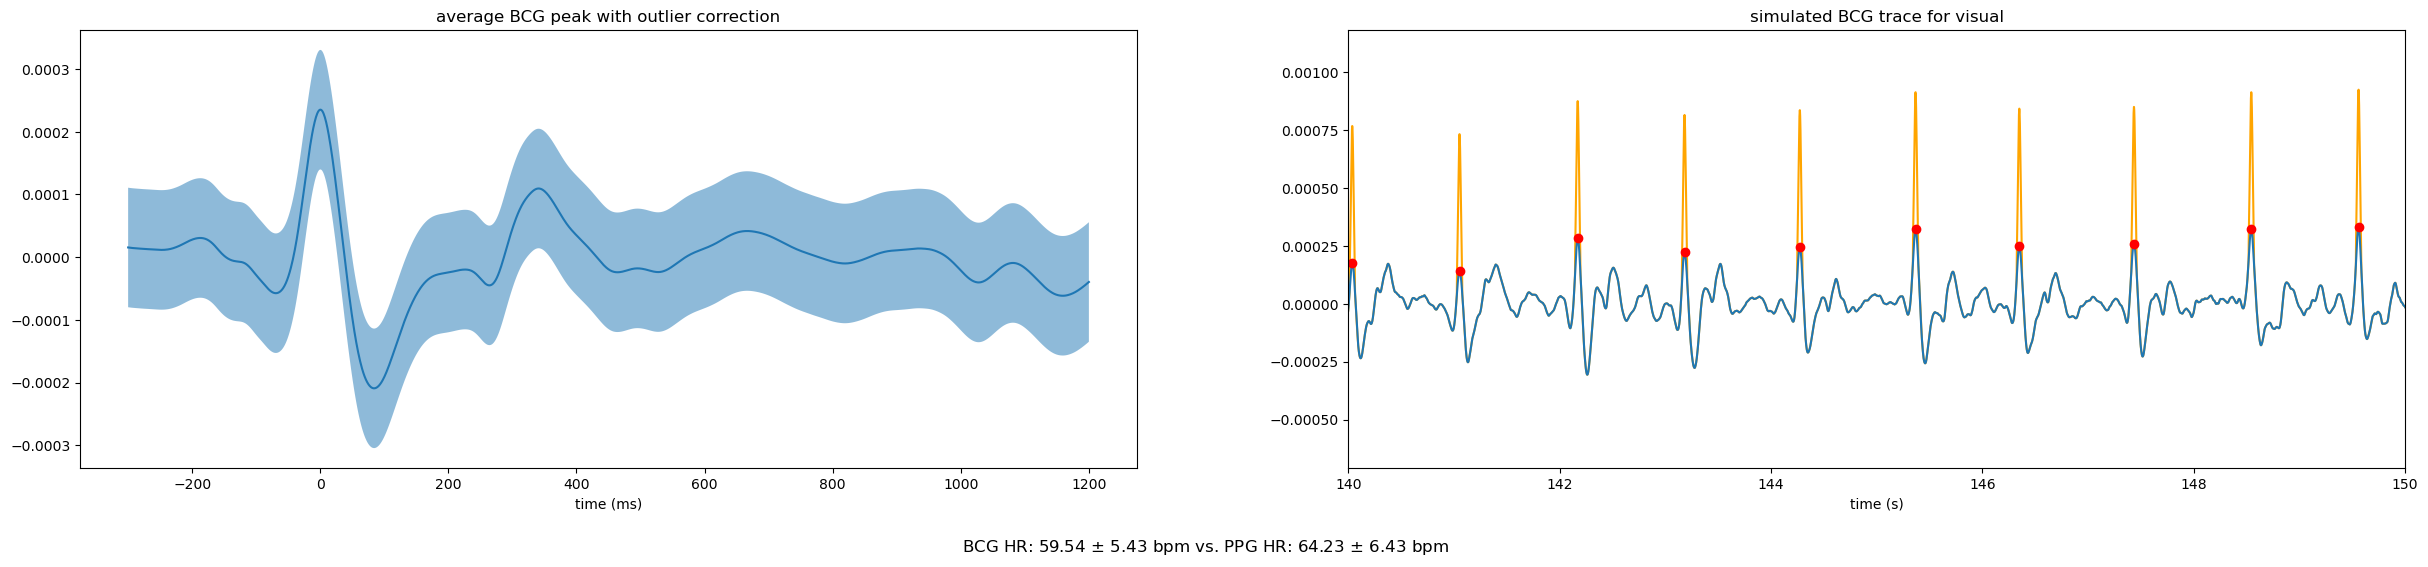

In [ ]:
from scipy.signal import find_peaks
import copy

smoothing = 1

for i, EEG_i in enumerate(EEG_segs):

    print("Now simulating BCG detection channel for", EEG_segs_labels[i])

    if i < 2:
        PPG_HRs = PPG_metrics[i]
        #[mean_HR max_HR std_HR ms_between_HR]
        min_distance = PPG_HRs[3]-10;
    # otherwise for the visual segment, use the breathing data, since this data is not currently used or pre-processed

    BCG = BCGs[i]
    ecg_old, times = EEG_i.get_data(picks='ecg',return_times=True)

    if smoothing == 1:
        window_size = 35
        kernel = np.ones(window_size) / window_size
        smoothed_BCG = np.convolve(BCG, kernel, mode='same')
        BCG = smoothed_BCG
        
 
    min_peaks = find_peaks(-BCG,distance=min_distance)
    min_peaks=np.squeeze([min_peaks[0]])
    peaks = list()
    pre_search_window = 180 # ms to search for maximum    
    # now find the corresponding positive peaks
    for j, min_peak in enumerate(min_peaks):
        if min_peak-pre_search_window < 0:
            pass
        else:
            max_peak_ind = np.argmax(BCG[min_peak-pre_search_window:min_peak])
            peaks.append(min_peak-pre_search_window+max_peak_ind)
    peaks = np.array(peaks)
    peaks = peaks.reshape((1,len(peaks)))

    if subject_id == '5931':
        peaks = find_peaks(BCG,distance=min_distance)
        peaks = [peaks[0]]
    

    # calculate HR during the scan
    peak_times = times[peaks]
    peak_dist = np.diff(peak_times)
    median_HR = 60/np.median(peak_dist)
    mean_HR = 60/np.mean(peak_dist)
    std_HR = np.std(60/peak_dist)
    print('The simulated BCG channel has a base mean HR of: ',mean_HR,' compared to the PPG mean:',PPG_HRs[0])
    print('The simulated BCG channel has a base std HR of: ',std_HR,' compared to the PPG std:',PPG_HRs[2])

    # do some outlier handling
    peak_dist = np.squeeze(np.diff(peaks))
    outlier_margin=0.3
    remove_j = list()
    dist_kept = list()
    wonky_prev = False
    for j, peak_d in enumerate(peak_dist):
        if j < 5:
            pass
        else:
            # look at the previous distances
            if wonky_prev == False:
                mean_prev = np.mean(peak_dist[j-5:j])
            if peak_d < (1-outlier_margin)*mean_prev:
                remove_j.append(j)
                wonky_prev = True
            elif peak_d > (1+outlier_margin)*mean_prev:
                remove_j.append(j)
                wonky_prev = True
            else:
                dist_kept.append(peak_d)
                wonky_prev = False
    peaks = np.delete(peaks,remove_j,axis=1)


    mean_peak_height = np.abs(np.mean(BCG[peaks]))
    #plt.figure(figsize=(20,5))
    snip = [140, 150]
    #plt.plot(times,BCG)
    #plt.plot(times[peaks],BCG[peaks],marker='o')
    #plt.xlim(times[snip])
    #plt.ylim([-1.5*mean_peak_height,2*mean_peak_height])
    #plt.title(EEG_segs_labels[i])

    # calculate HR during the scan
    peak_times = times[peaks]
    peak_dist = np.diff(peak_times)
    median_HR = 60/np.median(peak_dist)
    mean_HR = 60*1000/np.mean(dist_kept)
    std_HR = np.std(60/peak_dist)
    print('The simulated BCG channel has a corrected mean HR of: ',mean_HR,' compared to the PPG mean:',PPG_HRs[0])
    print('The simulated BCG channel has a corrected std HR of: ',std_HR,' compared to the PPG std:',PPG_HRs[2])

    # now add a simulated peak to help with later detection
    n_samp = 50 # width-ish
    x = np.linspace(-10,10,n_samp)
    def gaussian(x, mu, sig):
        return (
            1.0 / (np.sqrt(2.0 * np.pi) * sig) * np.exp(-np.power((x - mu) / sig, 2.0) / 2)
        )
    y = gaussian(x,0,n_samp/10)
    y = y*2.5*mean_peak_height/np.max(y)

    # prepare to add the simulated peak
    BCG_mod = copy.deepcopy(BCG)
    peaks_sq = np.squeeze(peaks)

    # also pre-simulated peak, prepare an average BCG artefact for QC
    peak_window = 1500
    prepeak_window = 300
    postpeak_window = peak_window-prepeak_window
    avg_peak = np.zeros((1,peak_window))
    all_peaks = np.zeros((len(peaks_sq),peak_window))

    for j, peak in enumerate(peaks_sq):
        start = int(peak-n_samp/2)
        stop = int(peak+n_samp/2)
        start_offset = 0
        stop_offset = 0
        if start < 0:
            start_offset = -start
            start = 0        
        if stop > len(BCG)-1:
            stop_offset = stop - len(BCG)#-1
            stop = len(BCG)#-1
        ystart = 0 + start_offset
        ystop = len(y) - stop_offset
        BCG_mod[start:stop] = BCG[start:stop]+y[ystart:ystop]

        # also prepare an average peak to plot
        if peak-prepeak_window > 0:
            if peak+postpeak_window < len(BCG):
                avg_peak += BCG[peak-prepeak_window:peak+postpeak_window]
                all_peaks[j,:] = BCG[peak-prepeak_window:peak+postpeak_window]
    
    # prepare plot of average peak   
    avg_peak = np.squeeze(avg_peak/len(peaks_sq))
    all_peaks[~np.all(all_peaks == 0, axis=1)]
    error = np.std(all_peaks)
    avg_time = np.linspace(-prepeak_window,postpeak_window,peak_window)

    fig = plt.figure(figsize=(30,6))
    axes = fig.subplots(nrows=1, ncols=2)
    ax1, ax2 = axes.flatten()
    ax1.plot(avg_time,avg_peak)
    ax1.fill_between(avg_time, avg_peak-error, avg_peak+error,alpha=0.5)
    ax1.set_title('average BCG peak with outlier correction')
    ax1.set_xlabel('time (ms)')
    ax2.plot(times,BCG_mod,color='orange',label='simulated peak')
    ax2.plot(times,BCG,label='simulated BCG')
    ax2.plot(times[peaks],BCG[peaks],marker='o',color='red',label='detected peak')
    ax2.set_xlim(snip)
    ax2.set_ylim([-3*mean_peak_height,5*mean_peak_height])
    ax2.set_title(('simulated BCG trace for '+EEG_segs_labels[i]))
    ax2.set_xlabel('time (s)')

    # add some text
    HR_summary = rf'BCG HR: {mean_HR:.{2}f} $\pm$ {std_HR:.{2}f} bpm vs. PPG HR: {PPG_HRs[0]:.{2}f} $\pm$ {PPG_HRs[2]:.{2}f} bpm'

    fig.text(0.5, 0.01, HR_summary,ha='center', fontsize=12, wrap=True)
    fig.subplots_adjust(bottom=0.15)

    QC_fig_path = fig_root+'BCG_QC_'+subject_id+'_'+EEG_segs_labels[i]+'.png'
    fig.savefig(QC_fig_path)

    # # generate a false ECG peak channel and append to data
    sfreq = EEG_i.info['sfreq'] # Match sampling frequency
    new_channel_name = 'BCG'
    new_channel_type = 'ecg' # or 'misc', 'stim', etc.
    info_bcg_channel = mne.create_info([new_channel_name], sfreq, [new_channel_type])
    bcg_channel = mne.io.RawArray(BCG_mod[np.newaxis, :], info_bcg_channel,verbose=False)
    EEG_i.add_channels([bcg_channel],force_update_info=True)

    # check that channel was added correctly
    #data_ecg = EEG_i.get_data(picks='ecg')
    #info = EEG_i.info
    #print(info["ch_names"])
    #plt.figure(figsize=(20,5))
    #plt.plot(times,data_ecg[0,:])
    #plt.plot(times,data_ecg[1,:])


Finally, export the new EEG scans!

In [ ]:
for i, EEG_i in enumerate(EEG_segs):

    # right now, only want to deal with rest and breathing
    if i > 1:
        pass

    else:
        print("Now exporting new EEGlab dataset for", EEG_segs_labels[i])
        out_fname = output_root+subject_id+'_'+EEG_segs_labels[i]+'.set'
        mne.export.export_raw(out_fname, EEG_i, fmt='eeglab',overwrite=True)

